# Full LMT Mach-Zehnder simulation

Symmetric-LMT atom interferometer for Sr-87 on the 698 nm clock transition.
Atoms split into a **TOP** and **BOTTOM** cloud that fly apart, decelerate,
fly back together, and are recombined.

**Pulse groups**. Pulses come in groups of four. Inside a normal LMT group:

1. UP beam, addresses TOP cloud (Doppler-matched detuning).
2. DOWN beam, addresses BOTTOM cloud.
3. DOWN beam, addresses TOP cloud.
4. UP beam, addresses BOTTOM cloud.

After pulse 2 of every group both clouds sit in $|e\rangle$ — this is where
clearout pulses are applied to scrub parasitic ground-state branches.
Each group adds one $\hbar k$ to each arm in opposite directions (so 4×LMT
of momentum split per group).

**Beamsplitter groups**. The first group is a beamsplitter: its pulse 1 is
$\pi/2$ instead of $\pi$.  This takes a single ground cloud and turns it
into a TOP/BOTTOM pair.  The final group has pulse 4 replaced with
$\pi/2$ to recombine.

**Structure for the simulation**:

| group | role |
|-------|------|
| 1 | BS1 — split |
| 2 .. $N_{\rm acc}+1$ | accelerate apart |
| $N_{\rm acc}+2$ .. $N_{\rm groups}-1$ | decelerate, bringing momenta together |
| $N_{\rm groups}$ | BS2 — recombine |

with $N_{\rm acc} = N_{\rm groups}/2 - 1$ so the deceleration exactly
reverses the acceleration. This is the simple "diamond" trajectory without
a separate mirror pulse — adequate to study Gaussian-beam contrast loss vs
cloud size.

All parameters live at the top — edit them and rerun. Plot titles are
generated from the variable values.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
from scipy import constants

import lmt_simulation as sim

plt.rcParams["figure.figsize"] = (10, 6)
%matplotlib inline

## Parameters

All experimentally-meaningful parameters live in this cell.

In [2]:
# ----- Laser beams ----------------------------------------------------------
T_PI_UP = 65e-6                       # π-time on the up beam (s)
T_PI_DOWN = 85e-6                     # π-time on the down beam (s)
BEAM_WAIST = 1.3e-3 / 2               # 1/e² intensity radius w₀ (= 1/e² diameter / 2) (m)

# ----- Velocity selection ---------------------------------------------------
T_PI_VEL_SEL = 380e-6                 # velocity-selection π-pulse duration (s)

# ----- Atom cloud -----------------------------------------------------------
TEMPERATURE_INITIAL = 1e-6            # initial cloud temperature (K)
CLOUD_SIGMAS = np.logspace(np.log10(10e-6), np.log10(1e-3), 5)  # 1σ widths (m), 5 values

# ----- Interferometer -------------------------------------------------------
N_GROUPS = 8                          # total pulse-groups (must be even, ≥ 4)
N_CLEAROUT = 3                        # clearouts applied at the midpoint of the last N_CLEAROUT groups

# ----- Phase scan -----------------------------------------------------------
N_PHASE_POINTS = 5                    # φ points across [0, 2π)
N_ATOMS_PER_POINT = 100               # MC trials per (cloud σ, φ) point

# ----- Numerical ------------------------------------------------------------
PRUNE_THRESHOLD = 1e-6                # drop state rows with |amplitude|² below this
RNG_SEED = 12345

# ----- Derived (don't edit) ------------------------------------------------
RABI_UP = 1.0 / (2 * T_PI_UP)
RABI_DOWN = 1.0 / (2 * T_PI_DOWN)
RABI_VEL_SEL = 1.0 / (2 * T_PI_VEL_SEL)
SIGMA_V = np.sqrt(constants.k * TEMPERATURE_INITIAL / sim.MASS_ATOM)
DELTA_REC = sim.RECOIL_FREQUENCY_HZ
DOPPLER_SIGMA_HZ = SIGMA_V / sim.TRANSITION_WAVELENGTH
N_LMT_TOTAL_PULSES = 4 * N_GROUPS     # total laser pulses in the LMT sequence
N_ACC = N_GROUPS // 2 - 1             # accel groups between BS1 and the apex

assert N_GROUPS % 2 == 0 and N_GROUPS >= 4, "N_GROUPS must be even and ≥ 4"
assert 0 <= N_CLEAROUT <= N_GROUPS, "N_CLEAROUT must be in [0, N_GROUPS]"

print(f"T_PI_UP        = {T_PI_UP * 1e6:7.1f} µs  (Ω_up      = {RABI_UP:6.0f} Hz)")
print(f"T_PI_DOWN      = {T_PI_DOWN * 1e6:7.1f} µs  (Ω_down    = {RABI_DOWN:6.0f} Hz)")
print(f"T_PI_VEL_SEL   = {T_PI_VEL_SEL * 1e6:7.1f} µs  (Ω_vel_sel = {RABI_VEL_SEL:6.0f} Hz)")
print(f"beam waist w₀  = {BEAM_WAIST * 1e3:7.3f} mm (1/e² intensity radius)")
print()
print(f"T_initial          = {TEMPERATURE_INITIAL * 1e6:6.2f} µK")
print(f"σ_v                = {SIGMA_V * 1e3:6.2f} mm/s")
print(f"Doppler σ_f        = {DOPPLER_SIGMA_HZ:6.0f} Hz")
print(f"Recoil shift δ_rec = {DELTA_REC:6.0f} Hz")
print()
print(f"N_GROUPS          = {N_GROUPS}")
print(f"  → N_acc         = {N_ACC}  (accel groups between BS1 and the apex)")
print(f"  → N_dec         = {N_ACC}  (decel groups between the apex and BS2)")
print(f"  → total pulses  = {N_LMT_TOTAL_PULSES}")
print(f"N_CLEAROUT        = {N_CLEAROUT}  (midpoints of the last {N_CLEAROUT} groups)")
print(f"cloud σs / µm     = {CLOUD_SIGMAS * 1e6}")

T_PI_UP        =    65.0 µs  (Ω_up      =   7692 Hz)
T_PI_DOWN      =    85.0 µs  (Ω_down    =   5882 Hz)
T_PI_VEL_SEL   =   380.0 µs  (Ω_vel_sel =   1316 Hz)
beam waist w₀  =   0.650 mm (1/e² intensity radius)

T_initial          =   1.00 µK
σ_v                =   9.78 mm/s
Doppler σ_f        =  14006 Hz
Recoil shift δ_rec =   4707 Hz

N_GROUPS          = 8
  → N_acc         = 3  (accel groups between BS1 and the apex)
  → N_dec         = 3  (decel groups between the apex and BS2)
  → total pulses  = 32
N_CLEAROUT        = 3  (midpoints of the last 3 groups)
cloud σs / µm     = [  10.           31.6227766   100.          316.22776602 1000.        ]


## LMT pulse-group table

Each pulse-group has four pulses. Their up/down direction, detuning, and
the cloud they address depend on the group's role (BS1, accel, decel, BS2)
and where the LMT arms are at the start of the group.

After BS1 the two clouds sit at $m=+2$ (TOP) and $m=-2$ (BOTTOM) in the
ground state.  Each subsequent accel group adds $\pm2$ to TOP / $\mp 2$ to
BOTTOM. Decel groups reverse those kicks.

Detunings are chirped to match the Doppler-shifted resonance of the cloud
being addressed (assuming the velocity-selected slice sits at $v_z=0$):

$$\Delta = (2\,m_g\,k_{\rm sign} + 1)\,\delta_{\rm rec}$$

In [3]:
def _resonant_detuning(m_g, k_sign, delta_rec):
    """Detuning (Hz) that makes a |g,m_g⟩↔|e,m_g+k_sign⟩ pulse resonant at v_z=0."""
    return (2 * m_g * k_sign + 1) * delta_rec


def build_pulse_groups(
    n_groups, t_pi_up, t_pi_down, rabi_up, rabi_down, delta_rec
):
    """Build the full N_groups × 4-pulse sequence as a list of pulses.

    Returns a list of ``(k_sign, t_pulse, rabi_freq, detuning_hz, is_pi_half, label)``,
    plus the 1-indexed pulse index *just before* which each group's midpoint
    clearout would be applied (= group_start + 2 for each group).
    """
    n_acc = n_groups // 2 - 1
    pulses = []
    midpoint_indices = []  # 1-indexed pulse index of the "midpoint" of each group

    def add_group(role, m_top_before, batch_idx):
        """Append the four pulses of one group.

        - role: "BS1", "acc", "dec", "BS2"
        - m_top_before: m of TOP cloud entering the group (BOTTOM is -m_top_before).
        Both clouds enter the group in the ground state.
        """
        m_top = m_top_before
        m_bot = -m_top_before
        if role == "BS1" or role == "acc":
            # Pulse 1: UP-TOP drives TOP g→e (m_top → m_top+1)
            d1 = _resonant_detuning(m_top, +1, delta_rec)
            l1_role = "BS1 π/2" if role == "BS1" else "acc π"
            pulses.append((
                +1, t_pi_up / 2 if role == "BS1" else t_pi_up,
                rabi_up, d1, role == "BS1",
                f"G{batch_idx} #1 UP-TOP   ({l1_role})  m_g=+{m_top}",
            ))
            # Pulse 2: DOWN-BOTTOM drives BOTTOM g→e (m_bot → m_bot-1)
            d2 = _resonant_detuning(m_bot, -1, delta_rec)
            pulses.append((
                -1, t_pi_down, rabi_down, d2, False,
                f"G{batch_idx} #2 DOWN-BOT (acc π)   m_g={m_bot:+d}",
            ))
            midpoint_indices.append(len(pulses) + 1)  # 1-indexed pulse just after this midpoint
            # Pulse 3: DOWN-TOP drives TOP e→g (m_top+1 → m_top+2)
            d3 = _resonant_detuning(m_top + 2, -1, delta_rec)
            pulses.append((
                -1, t_pi_down, rabi_down, d3, False,
                f"G{batch_idx} #3 DOWN-TOP (acc π)   m_g=+{m_top + 2}",
            ))
            # Pulse 4: UP-BOTTOM drives BOTTOM e→g (m_bot-1 → m_bot-2)
            d4 = _resonant_detuning(m_bot - 2, +1, delta_rec)
            pulses.append((
                +1, t_pi_up, rabi_up, d4, False,
                f"G{batch_idx} #4 UP-BOT   (acc π)   m_g={m_bot - 2:+d}",
            ))
        else:
            # decel / BS2 — same as accel but with the four sub-pulse roles swapped
            # so that the net effect is TOP -2, BOTTOM +2.
            # Pulse 1: DOWN-TOP drives TOP g→e (m_top → m_top-1)
            d1 = _resonant_detuning(m_top, -1, delta_rec)
            pulses.append((
                -1, t_pi_down, rabi_down, d1, False,
                f"G{batch_idx} #1 DOWN-TOP (dec π)   m_g=+{m_top}",
            ))
            # Pulse 2: UP-BOTTOM drives BOTTOM g→e (m_bot → m_bot+1)
            d2 = _resonant_detuning(m_bot, +1, delta_rec)
            pulses.append((
                +1, t_pi_up, rabi_up, d2, False,
                f"G{batch_idx} #2 UP-BOT   (dec π)   m_g={m_bot:+d}",
            ))
            midpoint_indices.append(len(pulses) + 1)
            # Pulse 3: UP-TOP drives TOP e→g (m_top-1 → m_top-2)
            d3 = _resonant_detuning(m_top - 2, +1, delta_rec)
            pulses.append((
                +1, t_pi_up, rabi_up, d3, False,
                f"G{batch_idx} #3 UP-TOP   (dec π)   m_g=+{m_top - 2}",
            ))
            # Pulse 4: DOWN-BOTTOM drives BOTTOM e→g (m_bot+1 → m_bot+2)
            d4 = _resonant_detuning(m_bot + 2, -1, delta_rec)
            l4_role = "BS2 π/2" if role == "BS2" else "dec π"
            pulses.append((
                -1, t_pi_down / 2 if role == "BS2" else t_pi_down,
                rabi_down, d4, role == "BS2",
                f"G{batch_idx} #4 DOWN-BOT ({l4_role})  m_g={m_bot + 2:+d}",
            ))

    # BS1: arms start at (0, 0), end at (+2, -2)
    add_group("BS1", m_top_before=0, batch_idx=1)

    # Acceleration groups
    for b in range(n_acc):
        m_top_in = 2 * (b + 1)              # +2, +4, +6, ...
        add_group("acc", m_top_before=m_top_in, batch_idx=2 + b)

    # Deceleration groups
    m_top_apex = 2 * (n_acc + 1)            # apex momentum of TOP
    for d in range(n_acc):
        m_top_in = m_top_apex - 2 * d       # apex, apex-2, …, +4
        add_group("dec", m_top_before=m_top_in, batch_idx=2 + n_acc + d)

    # BS2: arms enter at (+2, -2), final π/2 recombines
    add_group("BS2", m_top_before=2, batch_idx=n_groups)

    return pulses, midpoint_indices


PULSES, MIDPOINTS = build_pulse_groups(
    N_GROUPS, T_PI_UP, T_PI_DOWN, RABI_UP, RABI_DOWN, DELTA_REC
)

# Clearouts: midpoints of the LAST N_CLEAROUT groups
CLEAROUT_BEFORE = set(MIDPOINTS[-N_CLEAROUT:]) if N_CLEAROUT > 0 else set()

print(f"Total pulses = {len(PULSES)} ({N_GROUPS} groups × 4)")
print(f"Group midpoint pulse indices (1-indexed): {MIDPOINTS}")
print(f"Clearouts applied before pulses: {sorted(CLEAROUT_BEFORE)}")
print()
print(f"{'idx':>3}  {'k':>2}  {'t/µs':>5}  {'Δ/δrec':>7}  label")
for i, (k, t_pulse, _rabi, det, _is_half, label) in enumerate(PULSES, start=1):
    marker = " ← clearout before" if i in CLEAROUT_BEFORE else ""
    print(f"{i:>3}  {k:>+2d}  {t_pulse * 1e6:>5.1f}  {det / DELTA_REC:>+7.1f}  {label}{marker}")

Total pulses = 32 (8 groups × 4)
Group midpoint pulse indices (1-indexed): [3, 7, 11, 15, 19, 23, 27, 31]
Clearouts applied before pulses: [23, 27, 31]

idx   k   t/µs   Δ/δrec  label
  1  +1   32.5     +1.0  G1 #1 UP-TOP   (BS1 π/2)  m_g=+0
  2  -1   85.0     +1.0  G1 #2 DOWN-BOT (acc π)   m_g=+0
  3  -1   85.0     -3.0  G1 #3 DOWN-TOP (acc π)   m_g=+2
  4  +1   65.0     -3.0  G1 #4 UP-BOT   (acc π)   m_g=-2
  5  +1   65.0     +5.0  G2 #1 UP-TOP   (acc π)  m_g=+2
  6  -1   85.0     +5.0  G2 #2 DOWN-BOT (acc π)   m_g=-2
  7  -1   85.0     -7.0  G2 #3 DOWN-TOP (acc π)   m_g=+4
  8  +1   65.0     -7.0  G2 #4 UP-BOT   (acc π)   m_g=-4
  9  +1   65.0     +9.0  G3 #1 UP-TOP   (acc π)  m_g=+4
 10  -1   85.0     +9.0  G3 #2 DOWN-BOT (acc π)   m_g=-4
 11  -1   85.0    -11.0  G3 #3 DOWN-TOP (acc π)   m_g=+6
 12  +1   65.0    -11.0  G3 #4 UP-BOT   (acc π)   m_g=-6
 13  +1   65.0    +13.0  G4 #1 UP-TOP   (acc π)  m_g=+6
 14  -1   85.0    +13.0  G4 #2 DOWN-BOT (acc π)   m_g=-6
 15  -1   85.0    -1

## Spacetime diagram

Deterministic spacetime trajectory of the two interferometer arms, built directly from the pulse table — no Monte Carlo. Time on the x-axis, longitudinal position $z$ on the y-axis. Each cloud is in $|g, m\rangle$ or $|e, m\rangle$ with velocity $v = m\,v_{\rm recoil}$ between pulses. The cloud addressed by a pulse exchanges one $\hbar k$ (sign set by beam direction and $g\!\to\!e$ vs $e\!\to\!g$); the unaddressed cloud propagates ballistically. Position during a pulse uses the midpoint approximation, matching `pulse_interaction_in_borde_representation`.

**The diamond does not close yet.** My LMT block has only the BS1 → accel → decel → BS2 phases from the simulation cells above; the arms diverge during accel, decelerate symmetrically back to $(\pm 2)\,\hbar k$, then BS2 fires. Velocities never change sign so the position trajectory is monotonically outward — the diagram looks like an opening lens, not a bowtie. To close into a real diamond I'd need to add the mirror / accel-together / decel-overlap phases from your earlier message (continue deceleration *past* $(\pm 2)\,\hbar k$ down to $(\mp M, \pm M)$, then a second deceleration leg back to $(\mp 2, \pm 2)$ for BS2). Happy to wire that up next — let me know.

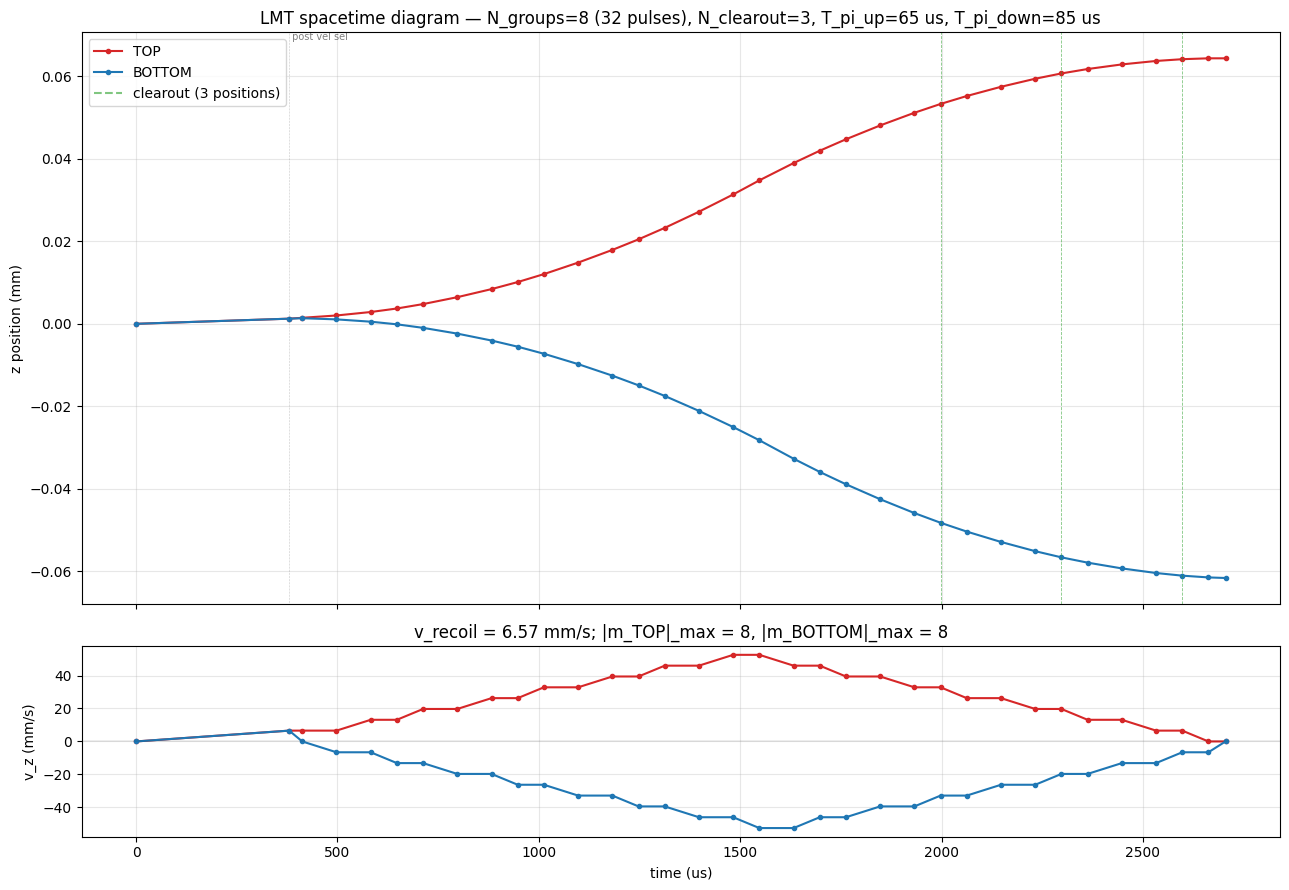

In [4]:
def compute_spacetime_trajectory(pulses, t_pi_vel_sel, v_recoil):
    """Deterministic spacetime trajectory of the TOP and BOTTOM clouds.

    Returns parallel arrays of (time, z_top, z_bot, v_top, v_bot, m_top, m_bot,
    state_top, state_bot, label), one entry per "event" (pulse boundary).
    """
    top = {"z": 0.0, "v": 0.0, "m": 0, "state": "g"}
    bot = dict(top)
    bottom_exists = False

    def _flip(cloud, k_sign, t_pulse):
        if cloud["state"] == "g":
            dm = +k_sign
            new_state = "e"
        else:
            dm = -k_sign
            new_state = "g"
        m_new = cloud["m"] + dm
        v_new = m_new * v_recoil
        cloud["z"] = cloud["z"] + 0.5 * (cloud["v"] + v_new) * t_pulse
        cloud["v"] = v_new
        cloud["m"] = m_new
        cloud["state"] = new_state

    def _drift(cloud, t_pulse):
        cloud["z"] = cloud["z"] + cloud["v"] * t_pulse

    times = [0.0]
    z_top_list, z_bot_list = [top["z"]], [bot["z"]]
    v_top_list, v_bot_list = [top["v"]], [bot["v"]]
    m_top_list, m_bot_list = [top["m"]], [bot["m"]]
    s_top_list, s_bot_list = [top["state"]], [bot["state"]]
    labels = [""]

    t = 0.0

    # Velocity-selection pulse drives the single cloud |g,0> -> |e,+1>
    _flip(top, +1, t_pi_vel_sel)
    bot.update({k: top[k] for k in ("z", "v", "m", "state")})
    t += t_pi_vel_sel
    times.append(t)
    z_top_list.append(top["z"]); z_bot_list.append(bot["z"])
    v_top_list.append(top["v"]); v_bot_list.append(bot["v"])
    m_top_list.append(top["m"]); m_bot_list.append(bot["m"])
    s_top_list.append(top["state"]); s_bot_list.append(bot["state"])
    labels.append("vel sel (UP-TOP)")

    for k_sign, t_pulse, _rabi, _det, _is_half, label in pulses:
        addresses_top = "-TOP" in label
        addresses_bot = "-BOT" in label
        assert addresses_top ^ addresses_bot, "label must address exactly one cloud: " + label

        if (not bottom_exists) and addresses_top and ("BS1" in label):
            # BS1 pulse 1 splits the single cloud into TOP (unchanged) and BOTTOM (|e,+1>->|g,0>).
            _drift(top, t_pulse)
            _flip(bot, k_sign, t_pulse)
            bottom_exists = True
        else:
            target = top if addresses_top else bot
            other = bot if addresses_top else top
            _flip(target, k_sign, t_pulse)
            _drift(other, t_pulse)

        t += t_pulse
        times.append(t)
        z_top_list.append(top["z"]); z_bot_list.append(bot["z"])
        v_top_list.append(top["v"]); v_bot_list.append(bot["v"])
        m_top_list.append(top["m"]); m_bot_list.append(bot["m"])
        s_top_list.append(top["state"]); s_bot_list.append(bot["state"])
        labels.append(label)

    return (
        np.asarray(times),
        np.asarray(z_top_list),
        np.asarray(z_bot_list),
        np.asarray(v_top_list),
        np.asarray(v_bot_list),
        np.asarray(m_top_list),
        np.asarray(m_bot_list),
        s_top_list,
        s_bot_list,
        labels,
    )


_v_recoil = sim.RECOIL_VELOCITY
times, z_top, z_bot, v_top, v_bot, m_top, m_bot, s_top, s_bot, labels = (
    compute_spacetime_trajectory(PULSES, T_PI_VEL_SEL, _v_recoil)
)

fig, (ax_z, ax_v) = plt.subplots(
    2, 1, figsize=(13, 9), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)

ax_z.plot(times * 1e6, z_top * 1e3, "-o", color="tab:red", ms=3, label="TOP")
ax_z.plot(times * 1e6, z_bot * 1e3, "-o", color="tab:blue", ms=3, label="BOTTOM")

t_post_vs = T_PI_VEL_SEL
ax_z.axvline(t_post_vs * 1e6, color="k", lw=0.4, linestyle=":", alpha=0.4)
ax_z.text(t_post_vs * 1e6, ax_z.get_ylim()[1], " post vel sel",
          va="top", ha="left", fontsize=7, alpha=0.5)

for clearout_idx in sorted(CLEAROUT_BEFORE):
    t_clearout = times[1 + (clearout_idx - 1)]
    ax_z.axvline(t_clearout * 1e6, color="tab:green", lw=0.6, alpha=0.6, linestyle="--")
if CLEAROUT_BEFORE:
    ax_z.plot([], [], color="tab:green", linestyle="--", alpha=0.6,
              label=f"clearout ({N_CLEAROUT} positions)")

ax_z.set_ylabel("z position (mm)")
ax_z.set_title(
    f"LMT spacetime diagram — N_groups={N_GROUPS} ({N_LMT_TOTAL_PULSES} pulses), "
    f"N_clearout={N_CLEAROUT}, T_pi_up={T_PI_UP * 1e6:.0f} us, T_pi_down={T_PI_DOWN * 1e6:.0f} us"
)
ax_z.legend(loc="upper left")
ax_z.grid(True, alpha=0.3)

v_recoil_mm_s = _v_recoil * 1e3
ax_v.plot(times * 1e6, v_top * 1e3, "-o", color="tab:red", ms=3, label="TOP")
ax_v.plot(times * 1e6, v_bot * 1e3, "-o", color="tab:blue", ms=3, label="BOTTOM")
ax_v.axhline(0, color="k", lw=0.3, alpha=0.3)
ax_v.set_xlabel("time (us)")
ax_v.set_ylabel("v_z (mm/s)")
ax_v.set_title(
    f"v_recoil = {v_recoil_mm_s:.2f} mm/s; "
    f"|m_TOP|_max = {int(np.abs(m_top).max())}, |m_BOTTOM|_max = {int(np.abs(m_bot).max())}"
)
ax_v.grid(True, alpha=0.3)

fig.tight_layout()


## Single-atom simulation

Runs the full sequence for one atom drawn from the cloud:

1. Initial position $(x_0, y_0, z_0)$ from a 3D Gaussian (one $\sigma$ per axis).
2. Initial $v_z$ from a 1D Maxwell–Boltzmann at $T_{\text{initial}}$.
3. Velocity-selection $\pi$ pulse + clearout.
4. The 4×$N_{\rm groups}$ LMT pulses with the chirped detunings above; clearouts
   at the midpoints of the last $N_{\rm clearout}$ groups (where both clouds
   are in $|e\rangle$).
5. Returns ``(P_g, P_e, n_rows)`` for survivors, or ``None`` if discarded.

After each pulse, rows whose $|\tilde{c}|^2 <$ ``PRUNE_THRESHOLD`` are
dropped to keep the row count bounded.

In [5]:
def _prune(state, threshold):
    m, sq, isg, pos, vel = state
    keep = np.abs(sq) ** 2 > threshold
    if not keep.any():
        return None
    return m[keep], sq[keep], isg[keep], pos[keep], vel[keep]


def run_single_atom(
    x0, y0, z0, vz0,
    beam_waist, pulses, clearout_before,
    t_pi_vel_sel, rabi_vel_sel, delta_rec,
    final_phi, prune_threshold, rng,
):
    """Run vel sel + LMT MZ for a single atom. Returns ``(P_g, P_e, n_rows)`` or ``None``.

    ``final_phi`` is applied as the laser phase of the *last* pulse in the
    sequence (the BS2 π/2).  Scanning ``final_phi`` traces out the
    interferometer fringe.
    """
    n_total = len(pulses)

    # ---- Initial state -----------------------------------------------
    m, pos, vel, amp, isg = sim.make_atom_states(
        position_x=x0, position_y=y0, position_z=z0,
        velocity_x=0.0, velocity_y=0.0, initial_velocity_z=vz0,
        c0=1.0, c1=0.0,
    )

    # ---- Velocity selection -----------------------------------------
    det_vs = +delta_rec
    omega_laser_vs = 2 * np.pi * (sim.TRANSITION_FREQUENCY + det_vs)
    sq = sim.transform_state_vector(
        m, amp, isg, omega_laser=omega_laser_vs, t=0.0, z=0.0, vz=vz0, inverse=False
    )
    m, sq, isg, pos, vel = sim.do_gaussian_pulse(
        m, sq, isg, pos, vel,
        pulse_detuning=det_vs,
        t_pulse=t_pi_vel_sel,
        on_axis_rabi_freq=rabi_vel_sel,
        beam_waist=beam_waist,
        pulse_phase=0.0,
        k_sign=+1,
        vz=vz0,
    )
    pruned = _prune((m, sq, isg, pos, vel), prune_threshold)
    if pruned is None:
        return None
    m, sq, isg, pos, vel = pruned

    result = sim.do_clearout(m, sq, isg, pos, vel, rng=rng)
    if result is None:
        return None
    m, sq, isg, pos, vel = result

    # ---- LMT sequence ----------------------------------------------
    for n, (k_sign, t_pulse, rabi, det, _is_half, _label) in enumerate(pulses, start=1):
        if n in clearout_before:
            result = sim.do_clearout(m, sq, isg, pos, vel, rng=rng)
            if result is None:
                return None
            m, sq, isg, pos, vel = result

        pulse_phase = final_phi if n == n_total else 0.0
        m, sq, isg, pos, vel = sim.do_gaussian_pulse(
            m, sq, isg, pos, vel,
            pulse_detuning=det,
            t_pulse=t_pulse,
            on_axis_rabi_freq=rabi,
            beam_waist=beam_waist,
            pulse_phase=pulse_phase,
            k_sign=k_sign,
            vz=vz0,
        )
        pruned = _prune((m, sq, isg, pos, vel), prune_threshold)
        if pruned is None:
            return None
        m, sq, isg, pos, vel = pruned

    # ---- Readout in lab frame ---------------------------------------
    omega_laser_end = 2 * np.pi * (sim.TRANSITION_FREQUENCY + delta_rec)
    amp_lab = sim.transform_state_vector(
        m, sq, isg, omega_laser=omega_laser_end, t=0.0, z=0.0, vz=vz0, inverse=True
    )
    pg, pe = sim.calculate_ground_and_excited_probabilities(m, amp_lab, isg)
    return pg, pe, len(m)

### Smoke test

Cold on-axis atom at $\phi=0$.  Should return a non-``None`` state
(both arms still alive at BS2).

In [6]:
smoke_rng = np.random.default_rng(RNG_SEED)
tic = time.time()
smoke = run_single_atom(
    x0=0.0, y0=0.0, z0=0.0, vz0=0.0,
    beam_waist=BEAM_WAIST, pulses=PULSES, clearout_before=CLEAROUT_BEFORE,
    t_pi_vel_sel=T_PI_VEL_SEL, rabi_vel_sel=RABI_VEL_SEL,
    delta_rec=DELTA_REC,
    final_phi=0.0, prune_threshold=PRUNE_THRESHOLD, rng=smoke_rng,
)
print(f"Smoke-test (φ=0, on-axis, vz=0): {smoke}")
print(f"Elapsed: {time.time() - tic:.2f} s")

Smoke-test (φ=0, on-axis, vz=0): (np.float64(0.05510837198472856), np.float64(0.9463239548695949), 184)
Elapsed: 0.25 s


## Sweep over cloud sizes and interferometer phase

For each cloud $\sigma$ in ``CLOUD_SIGMAS`` we run ``N_ATOMS_PER_POINT``
Monte-Carlo trials at each of ``N_PHASE_POINTS`` phase points spanning
$[0, 2\pi)$.  Each trial samples $(x_0, y_0, z_0)$ from
$\mathcal{N}(0, \sigma)$ in each axis and $v_z$ from $\mathcal{N}(0, \sigma_v)$.

Surviving trials contribute their $P_g$, $P_e$ weighted by
$1/N_{\text{trials}}$; trials discarded mid-sequence contribute to
$P_{\rm discarded}$ so $P_g + P_e + P_{\rm discarded} = 1$ in expectation.

In [7]:
phi_values = np.linspace(0.0, 2.0 * np.pi, N_PHASE_POINTS, endpoint=False)

p_ground = np.zeros((len(CLOUD_SIGMAS), N_PHASE_POINTS))
p_excited = np.zeros((len(CLOUD_SIGMAS), N_PHASE_POINTS))
p_discarded = np.zeros((len(CLOUD_SIGMAS), N_PHASE_POINTS))

global_rng = np.random.default_rng(RNG_SEED)

tic = time.time()
for i_sigma, cloud_sigma in enumerate(CLOUD_SIGMAS):
    for j_phi, phi in enumerate(phi_values):
        ground_tally = 0.0
        excited_tally = 0.0
        discard_tally = 0.0
        for _ in range(N_ATOMS_PER_POINT):
            x0 = global_rng.normal(0.0, cloud_sigma)
            y0 = global_rng.normal(0.0, cloud_sigma)
            z0 = global_rng.normal(0.0, cloud_sigma)
            vz0 = global_rng.normal(0.0, SIGMA_V)
            res = run_single_atom(
                x0=x0, y0=y0, z0=z0, vz0=vz0,
                beam_waist=BEAM_WAIST, pulses=PULSES, clearout_before=CLEAROUT_BEFORE,
                t_pi_vel_sel=T_PI_VEL_SEL, rabi_vel_sel=RABI_VEL_SEL,
                delta_rec=DELTA_REC,
                final_phi=phi, prune_threshold=PRUNE_THRESHOLD, rng=global_rng,
            )
            if res is None:
                discard_tally += 1.0
            else:
                pg, pe, _nrows = res
                ground_tally += pg
                excited_tally += pe
        p_ground[i_sigma, j_phi] = ground_tally / N_ATOMS_PER_POINT
        p_excited[i_sigma, j_phi] = excited_tally / N_ATOMS_PER_POINT
        p_discarded[i_sigma, j_phi] = discard_tally / N_ATOMS_PER_POINT
    elapsed = time.time() - tic
    print(
        f"σ = {cloud_sigma * 1e6:6.1f} µm  done  "
        f"(⟨P_e⟩={p_excited[i_sigma].mean():.3f}, "
        f"⟨P_disc⟩={p_discarded[i_sigma].mean():.3f}, "
        f"elapsed {elapsed:.1f} s)"
    )

σ =   10.0 µm  done  (⟨P_e⟩=0.028, ⟨P_disc⟩=0.960, elapsed 13.4 s)
σ =   31.6 µm  done  (⟨P_e⟩=0.023, ⟨P_disc⟩=0.956, elapsed 27.3 s)
σ =  100.0 µm  done  (⟨P_e⟩=0.032, ⟨P_disc⟩=0.948, elapsed 40.9 s)
σ =  316.2 µm  done  (⟨P_e⟩=0.017, ⟨P_disc⟩=0.978, elapsed 49.1 s)
σ = 1000.0 µm  done  (⟨P_e⟩=0.004, ⟨P_disc⟩=0.996, elapsed 50.3 s)


## Plot 1 — fringes for each cloud size

$\langle P_e \rangle$ (averaged over MC trials, including the discarded
channel weighted by zero) as a function of the BS2 phase $\phi$ for each
cloud $\sigma$.

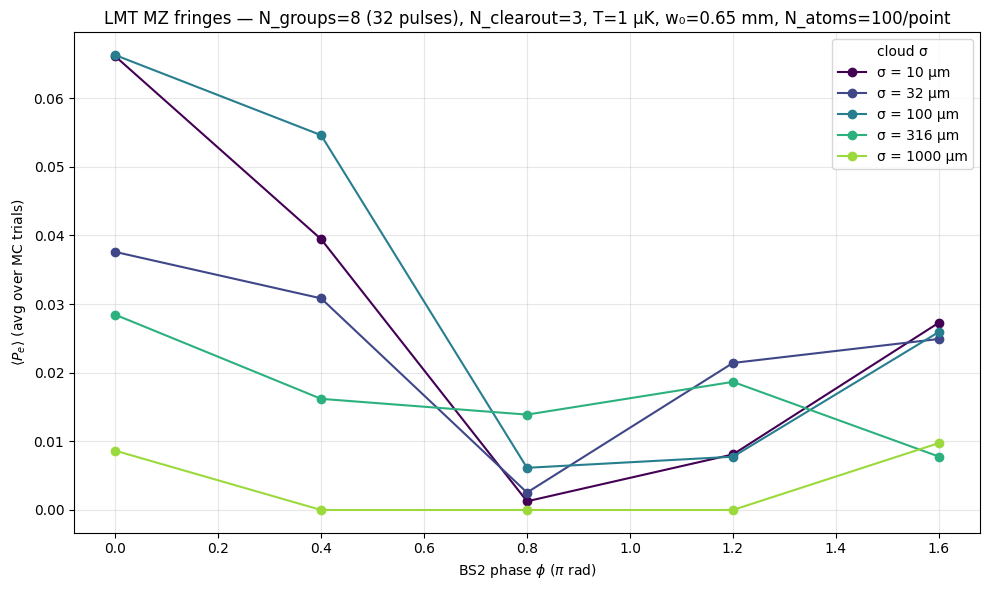

In [8]:
fig, ax = plt.subplots()
colours = plt.cm.viridis(np.linspace(0.0, 0.85, len(CLOUD_SIGMAS)))
for i, cloud_sigma in enumerate(CLOUD_SIGMAS):
    ax.plot(
        phi_values / np.pi,
        p_excited[i],
        "o-",
        color=colours[i],
        label=f"σ = {cloud_sigma * 1e6:.0f} µm",
    )
ax.set_xlabel(r"BS2 phase $\phi$ ($\pi$ rad)")
ax.set_ylabel(r"$\langle P_e \rangle$ (avg over MC trials)")
ax.set_title(
    f"LMT MZ fringes — N_groups={N_GROUPS} ({N_LMT_TOTAL_PULSES} pulses), "
    f"N_clearout={N_CLEAROUT}, T={TEMPERATURE_INITIAL * 1e6:.0f} µK, "
    f"w₀={BEAM_WAIST * 1e3:.2f} mm, N_atoms={N_ATOMS_PER_POINT}/point"
)
ax.grid(True, alpha=0.3)
ax.legend(title="cloud σ", loc="best")
fig.tight_layout()

## Plot 2 — fringe amplitude and Michelson contrast vs cloud size

Fringe amplitude $\Delta P_e = \max(P_e) - \min(P_e)$ tells you how much
absolute signal survives the interferometer; the Michelson contrast
$(\max - \min)/(\max + \min)$ tells you how visible the fringe is *among the
surviving atoms*.

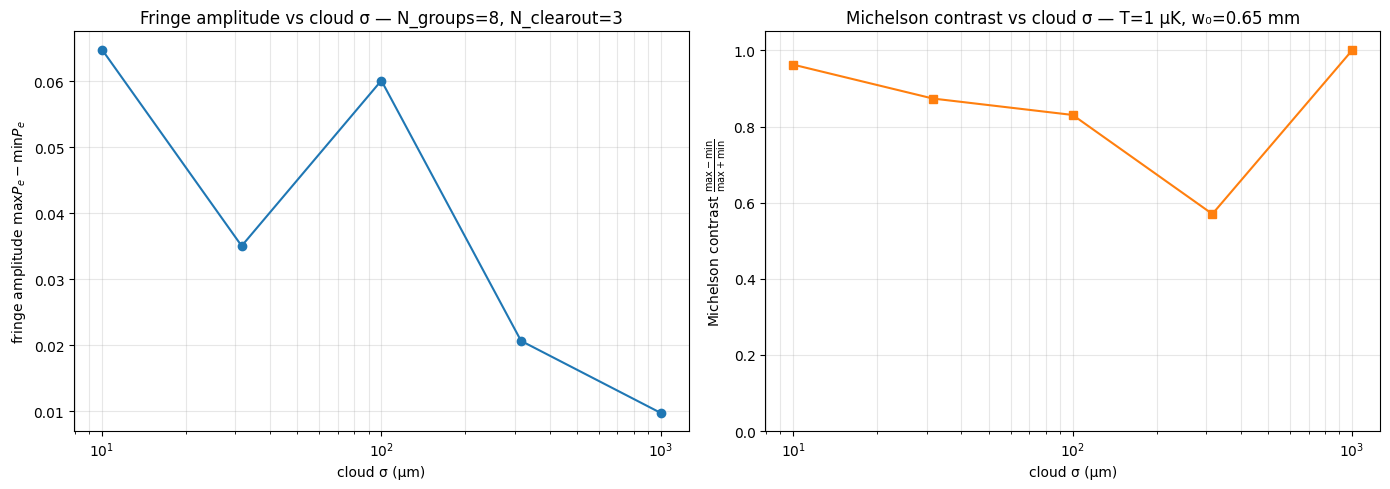

In [9]:
fringe_amplitude = p_excited.max(axis=1) - p_excited.min(axis=1)
fringe_offset = 0.5 * (p_excited.max(axis=1) + p_excited.min(axis=1))
michelson = np.where(fringe_offset > 0, fringe_amplitude / (2 * fringe_offset), 0.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogx(CLOUD_SIGMAS * 1e6, fringe_amplitude, "o-", color="tab:blue")
axes[0].set_xlabel("cloud σ (µm)")
axes[0].set_ylabel(r"fringe amplitude $\max P_e - \min P_e$")
axes[0].set_title(
    f"Fringe amplitude vs cloud σ — N_groups={N_GROUPS}, N_clearout={N_CLEAROUT}"
)
axes[0].grid(True, which="both", alpha=0.3)

axes[1].semilogx(CLOUD_SIGMAS * 1e6, michelson, "s-", color="tab:orange")
axes[1].set_xlabel("cloud σ (µm)")
axes[1].set_ylabel(r"Michelson contrast $\frac{\max - \min}{\max + \min}$")
axes[1].set_title(
    f"Michelson contrast vs cloud σ — T={TEMPERATURE_INITIAL * 1e6:.0f} µK, "
    f"w₀={BEAM_WAIST * 1e3:.2f} mm"
)
axes[1].grid(True, which="both", alpha=0.3)
axes[1].set_ylim(0.0, 1.05)

fig.tight_layout()

## Plot 3 — survival fraction vs cloud size

Fraction of MC trials that survive velocity selection and all in-sequence
clearouts.  Atoms far from the beam axis see a reduced Gaussian-beam Rabi
frequency, fail to flip cleanly on the vel-sel π pulse, and are dropped at
the first clearout — so this scales steeply with cloud σ / beam waist.

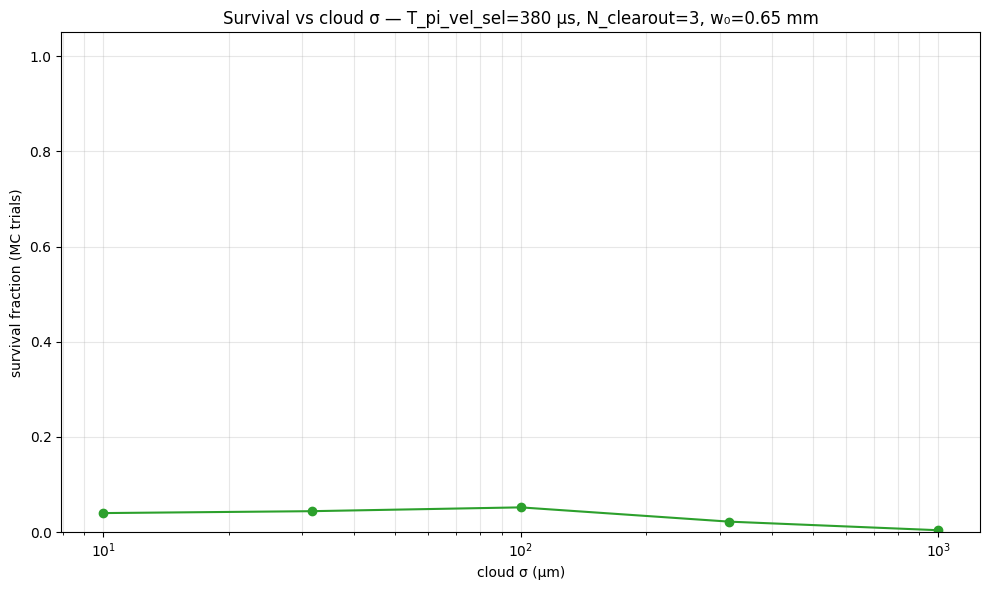

In [10]:
survival = 1.0 - p_discarded.mean(axis=1)

fig, ax = plt.subplots()
ax.semilogx(CLOUD_SIGMAS * 1e6, survival, "o-", color="tab:green")
ax.set_xlabel("cloud σ (µm)")
ax.set_ylabel("survival fraction (MC trials)")
ax.set_title(
    f"Survival vs cloud σ — T_pi_vel_sel={T_PI_VEL_SEL * 1e6:.0f} µs, "
    f"N_clearout={N_CLEAROUT}, w₀={BEAM_WAIST * 1e3:.2f} mm"
)
ax.grid(True, which="both", alpha=0.3)
ax.set_ylim(0.0, 1.05)
fig.tight_layout()